# 1. 멜론/벅스/지니 차트 크롤링 및 시각화
- 목표: 3대 뮤직 사이트 (Melon, Bugs, Genie)의 Top 100 차트를 크롤링합니다.
- 처리: 수집된 데이터에 순위별 가중치(1위=100점, 100위=1점)를 부여하여 종합 점수를 산출합니다.
- 결과: 엑셀 파일로 저장하고, 인기가수 및 인기곡을 시각화합니다.

In [1]:
# 필요한 라이브러리 설치 (필요시 주석 해제 후 실행)
# !pip install requests beautifulsoup4 pandas openpyxl matplotlib seaborn

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# 한글 폰트 설정 (Mac: AppleGothic, Windows: Malgun Gothic)
import platform
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')

plt.rcParams['axes.unicode_minus'] = False

## 1. 크롤링 함수 정의

In [3]:
# 크롤링을 위한 기본 세팅(자동화 봇 차단 방지)
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/90.0.4430.93 Safari/537.36'}
genre_yn = 'N'
genre_size = 0

In [4]:
def crawl_melon():
    print("Melon 크롤링 시작...")
    url = 'https://www.melon.com/chart/index.htm'
    
    try:
        res = requests.get(url, headers=headers)
        res.raise_for_status()
        soup = BeautifulSoup(res.text, 'html.parser')
        
        data = []
        # Melon은 50곡씩 tbody가 나뉘어 있을 수 있으나 보통 리스트 구조임. 
        # 정확한 셀렉터: #lst50, #lst100 두 그룹으로 나뉨
        songs = soup.select('tr.lst50') + soup.select('tr.lst100')
        
        i = 0
        for song in songs:
            rank = song.select_one('span.rank').text.strip()
            title = song.select_one('div.ellipsis.rank01 > span > a').text.strip()
            artists = song.select('div.ellipsis.rank02 > a')
            if len(artists) > 1:
                artist = ', '.join([artist.text.strip().replace(' (', '(') for artist in artists])
            else:
                artist = artists[0].text.strip().replace(' (', '(')
            album = song.select_one('div.ellipsis.rank03 > a').text.strip()
            
            data.append({
                'Site': 'Melon',
                'Rank': int(rank),
                'Title': title,
                'Artist': artist,
                'Album': album
            })

            if(genre_yn == 'Y' and i < genre_size):
                time.sleep(0.5)
                data_song_no = song.get('data-song-no')
                res2 = requests.get(f'https://www.melon.com/song/detail.htm?songId={data_song_no}', headers=headers)
                res2.raise_for_status()
                soup2 = BeautifulSoup(res2.text, 'html.parser')
                genre = soup2.select_one('#downloadfrm > .section_info .meta > dl > dd:nth-child(6)').text.strip()
                data[-1]['Genre'] = genre
                i += 1
            
        print(f"Melon {len(data)}곡 수집 완료")
        return data[:100]
    except Exception as e:
        print(f"Melon 크롤링 실패: {e}")
        return []

In [5]:
def crawl_bugs():
    print("Bugs 크롤링 시작...")
    url = 'https://music.bugs.co.kr/chart'
    
    try:
        res = requests.get(url, headers=headers)
        soup = BeautifulSoup(res.text, 'html.parser')
        
        data = []
        songs = soup.select('table.byChart > tbody > tr')
        
        for idx, song in enumerate(songs):
            if idx >= 100: break
            
            rank = song.select_one('div.ranking > strong').text.strip()
            title = song.select_one('p.title > a').text.strip()
            artists = song.select('p.artist > a')
            if len(artists) > 1:
                temp = artists[1].get('onclick')
                temp = temp.replace("""bugs.layermenu.openMultiArtistSearchResultPopLayer(this, '""", '')
                temp = temp.replace("""||OK', ''); return false;""", '')
                temp_artists = temp.split('||OK\\')
                temp_artists = [temp_artist.split('||')[1].strip().replace(' (', '(') for temp_artist in temp_artists]
                artist = ', '.join(temp_artists)
            else:
                artist = artists[0].text.strip().replace(' (', '(')
            album = song.select_one('a.album').text.strip()
            
            data.append({
                'Site': 'Bugs',
                'Rank': int(rank),
                'Title': title,
                'Artist': artist,
                'Album': album
            })
            
        print(f"Bugs {len(data)}곡 수집 완료")
        return data
    except Exception as e:
        print(f"Bugs 크롤링 실패: {e}")
        return []

In [6]:
def crawl_genie():
    print("Genie 크롤링 시작...")
    data = []
    
    try:
        i = 0
        # Genie는 페이지네이션 (1페이지: 1~50위, 2페이지: 51~100위)
        for page in range(1, 3):
            url = f'https://www.genie.co.kr/chart/top200?pg={page}'
            
            res = requests.get(url, headers=headers)
            soup = BeautifulSoup(res.text, 'html.parser')
            
            songs = soup.select('tbody > tr.list')
            for song in songs:
                rank_text = song.select_one('td.number').text.strip()
                rank = rank_text.split('\n')[0].strip() # '1\n유지' 형태 처리
                
                title = song.select_one('td.info > a.title').text.strip()
                artists = song.select_one('td.info > a.artist').text.split('&')
                if len(artists) > 1:
                    artist = ', '.join([artist.strip().replace(' (', '(') for artist in artists])
                else:
                    artist = artists[0].strip().replace(' (', '(')
                album = song.select_one('td.info > a.albumtitle').text.strip()
                
                data.append({
                    'Site': 'Genie',
                    'Rank': int(rank),
                    'Title': title,
                    'Artist': artist,
                    'Album': album
                })

                if(genre_yn == 'Y' and i < genre_size):
                    time.sleep(0.5)
                    songid = song.get('songid')
                    res2 = requests.get(f'https://www.genie.co.kr/detail/songInfo?xgnm={songid}', headers=headers)
                    res2.raise_for_status()
                    soup2 = BeautifulSoup(res2.text, 'html.parser')
                    genre = soup2.select('ul.info-data li')[2].select_one('span.value').text.split('/')[1].strip()
                    data[-1]['Genre'] = genre
                    i += 1
            
            time.sleep(0.5) # 매너 딜레이
            
        print(f"Genie {len(data)}곡 수집 완료")
        return data[:100]
    except Exception as e:
        print(f"Genie 크롤링 실패: {e}")
        return []


## 2. 데이터 수집 및 전처리

In [7]:
melon_data = crawl_melon()
bugs_data = crawl_bugs()
genie_data = crawl_genie()

all_data = melon_data + bugs_data + genie_data
df = pd.DataFrame(all_data)

# 데이터 확인
print("전체 데이터 개수:", len(df))
df.head()

Melon 크롤링 시작...
Melon 100곡 수집 완료
Bugs 크롤링 시작...
Bugs 100곡 수집 완료
Genie 크롤링 시작...
Genie 100곡 수집 완료
전체 데이터 개수: 300


,Site,Rank,Title,Artist,Album
0,Melon,1,Good Goodbye,화사(HWASA),Good Goodbye
1,Melon,2,타임캡슐,다비치,타임캡슐
2,Melon,3,Blue Valentine,NMIXX,Blue Valentine
3,Melon,4,ONE MORE TIME,ALLDAY PROJECT,ONE MORE TIME
4,Melon,5,Golden,"HUNTR/X, EJAE, AUDREY NUNA, REI AMI, KPop Demo...",KPop Demon Hunters (Soundtrack from the Netfli...


In [8]:
# 점수 부여 (1위: 100점, 100위: 1점)
df['Score'] = 101 - df['Rank']

# 엑셀 저장
file_name = 'music_charts.xlsx'
df.to_excel(file_name, index=False)
print(f"{file_name} 저장 완료")

music_charts.xlsx 저장 완료


## 3. 데이터 시각화

In [9]:
d_cnt = 20

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 201 (\N{LATIN CAPITAL LETTER E WITH ACUTE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


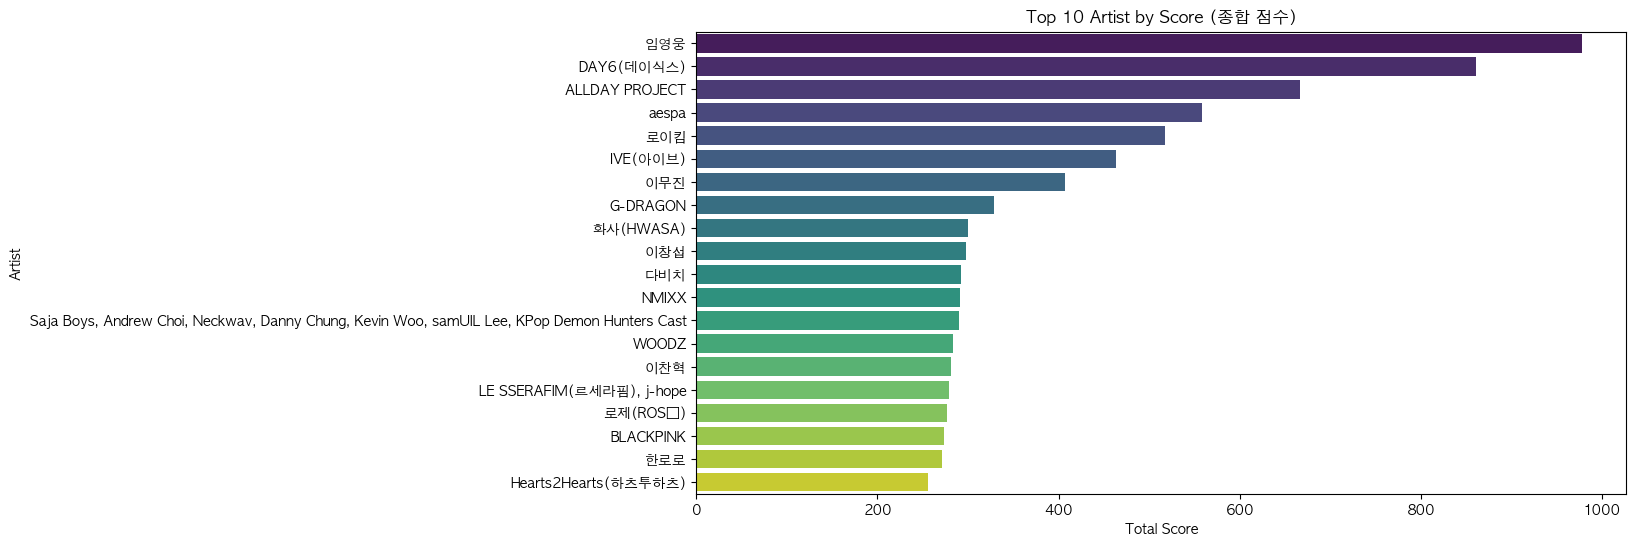

In [15]:
# 1. 가수별 종합 점수 Top 10
artist_score = df.groupby('Artist')['Score'].sum().sort_values(ascending=False).head(d_cnt)

plt.figure(figsize=(12, 6))
sns.barplot(x=artist_score.values, y=artist_score.index, hue=artist_score.index, palette='viridis', legend=False)
plt.title('Top 10 Artist by Score (종합 점수)')
plt.xlabel('Total Score')
plt.ylabel('Artist')
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 201 (\N{LATIN CAPITAL LETTER E WITH ACUTE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


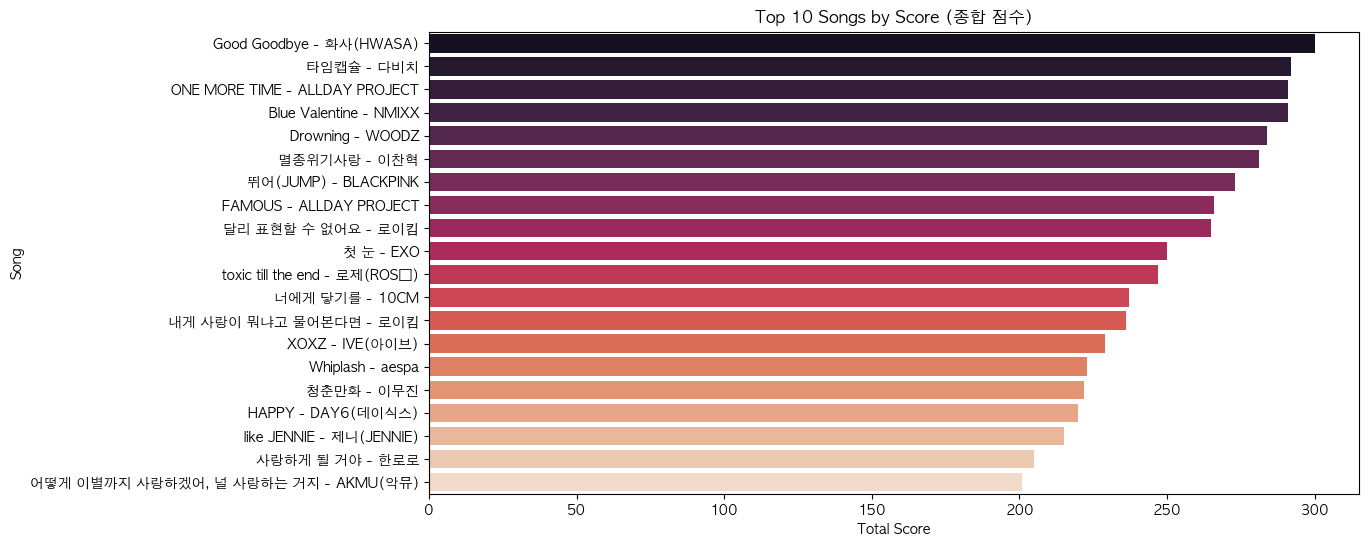

In [11]:
# 2. 곡별 종합 점수 Top 10
# 곡명과 가수가 같으면 같은 곡으로 간주
song_score = df.groupby(['Title', 'Artist'])['Score'].sum().sort_values(ascending=False).head(d_cnt)

# 시각화를 위해 인덱스(곡명, 가수)를 보기 좋게 합침
song_labels = [f"{title} - {artist}" for title, artist in song_score.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=song_score.values, y=song_labels, hue=song_labels, palette='rocket', legend=False)
plt.title('Top 10 Songs by Score (종합 점수)')
plt.xlabel('Total Score')
plt.ylabel('Song')
plt.show()

In [12]:
df.groupby(['Artist'])['Score'].sum().sort_index(ascending=True).iloc[0:20]

Artist
10CM                                                                                            237
AKMU(악뮤)                                                                                        201
ALLDAY PROJECT                                                                                  667
Ariana Grande                                                                                    68
Ariana Grande(아리아나 그란데)                                                                          28
BABYMONSTER                                                                                      98
BLACKPINK                                                                                       273
BOYNEXTDOOR                                                                                     219
DAY6(데이식스)                                                                                      861
DK(디셈버)                                                                                      

In [13]:
df.groupby(['Title'])['Score'].sum().sort_index(ascending=False).head(25)

Title
힙합보단 사랑, 사랑보단 돈 (Feat. 베이식)    144
희재                               1
헤어지자 말해요                        31
한번 더 이별                        144
한 페이지가 될 수 있게                  193
하얀 그리움                         128
타임캡슐                           292
청혼하지 않을 이유를 못 찾았어               50
청춘만화                           222
첫눈처럼 너에게 가겠다                    13
첫 만남은 계획대로 되지 않아                76
첫 눈                            250
천상연                            154
천국보다 아름다운                       49
주저하는 연인들을 위해                   103
잘 지내자, 우리 (여름날 우리 X 로이킴)        17
인사 (Panorama)                   55
인사                              30
운명 (2025)                      118
우리에게 안녕                         42
우리들의 블루스                       101
오늘만 I LOVE YOU                 114
예뻤어                            155
에피소드                           130
어제보다 슬픈 오늘                     177
Name: Score, dtype: int64

In [14]:
pd.DataFrame(genie_data).head(20)

,Site,Rank,Title,Artist,Album
0,Genie,1,Good Goodbye,화사(HWASA),Good Goodbye
1,Genie,2,타임캡슐,다비치,타임캡슐
2,Genie,3,Golden,"HUNTR/X, EJAE, Audrey Nuna, REI AMI, KPop Demo...",KPop Demon Hunters (Soundtrack from the Netfli...
3,Genie,4,Drowning,WOODZ,OO-LI
4,Genie,5,Blue Valentine,NMIXX,Blue Valentine
5,Genie,6,ONE MORE TIME,ALLDAY PROJECT,ONE MORE TIME
6,Genie,7,멸종위기사랑,이찬혁,EROS
7,Genie,8,뛰어(JUMP),BLACKPINK,뛰어(JUMP)
8,Genie,9,Soda Pop,"Saja Boys, Andrew Choi, Neckwav, Danny Chung, ...",KPop Demon Hunters (Soundtrack from the Netfli...
9,Genie,10,모르시나요 (Prod. by 로코베리),조째즈,모르시나요
